# Data learning curve — CNN-max & CNN-concat (curated peaks)

How does **test** peak-MAE improve as the **training set grows**? We hold out a **fixed 15% test set**
(seed 0) from the curated 758-sample dataset (**85/15** train/test), then train each model on increasing
fractions of the remaining **85% training pool** and evaluate on that same fixed test set.

- Architectures: **cnn-max** and **cnn-concat** (CNN over ESM-2 embeddings).
- **80 epochs** per fit (fixed, no val/early-stopping — we report test MAE after 80 epochs).
- Training-data fractions: **10% / 20% / 50% / 80% / 100%** of the 85% pool.
- Each train-size point is averaged over **3 random subset draws** (seeds 0–2) → mean ± std error bands.
- Targets standardized on each train subset; loss = standardized-peak MSE (Adam 1e-3, wd 1e-4, dropout 0.2).

## 0. Setup — curated data, embeddings, fixed test split

In [1]:
import csv, os, numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
def C(k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888"}.get(k,"#333")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
TD="training_data"; CUR=f"{TD}/curated"
rows=list(csv.DictReader(open(f"{CUR}/peak_assignments.csv"))); N=len(rows)
peaks=np.load(f"{CUR}/peaks.npy").astype(np.float32)
keep=np.load(f"{CUR}/keep_index.npy")
H=np.load(f"{TD}/esm_residue_fp16.npy")[keep]; Ls=np.load(f"{TD}/esm_residue_len.npy")[keep]
Lmax=int(Ls.max()); H=H[:,:Lmax]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
Pk=torch.tensor(peaks,device=dev)

# fixed held-out test set = 15% (seed 0); the rest (85%) is the training pool
perm=np.random.default_rng(0).permutation(N); n_te=int(round(0.15*N))
TEST=perm[:n_te]; POOL=perm[n_te:]
print(f"curated N={N} | fixed 15% test={len(TEST)} | 85% training pool={len(POOL)}")

def batches(idx,bs=32,shuffle=False,rng=None):
    idx=np.array(idx)
    if shuffle: rng.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]; yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
def test_mae(net,idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); T=peaks[idx]
    return 0.5*(np.abs(P[:,0]-T[:,0]).mean()+np.abs(P[:,1]-T[:,1]).mean())
def train_eval(pool, tr_idx, te_idx, seed):
    torch.manual_seed(seed); rng=np.random.default_rng(100+seed)
    mean=peaks[tr_idx].mean(0); std=peaks[tr_idx].std(0)+1e-6; sd=torch.tensor(std,device=dev)
    net=pm.wrap(pm.build_base(dict(arch="cnn",pool=pool,conv_ch=128,k=5,hidden=256,nl=2),dev,drop=0.2),mean,std,dev)
    opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=1e-4)
    for ep in range(80):
        net.train()
        for Hb,mk,b in batches(tr_idx,shuffle=True,rng=rng):
            opt.zero_grad(); (((net(Hb,mk)-Pk[torch.as_tensor(b,device=dev)])/sd)**2).mean().backward(); opt.step()
    return test_mae(net,te_idx), test_mae(net,tr_idx)

curated N=758 | fixed 15% test=114 | 85% training pool=644


## 1. Sweep training-set size (3 subset draws per point)

In [2]:
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; POOLS=["max","concat"]
res={p:{"n":[],"frac":[],"te_mean":[],"te_std":[],"tr_mean":[]} for p in POOLS}
for pool in POOLS:
    print(f"--- cnn-{pool} ---")
    for f in FRACS:
        n=int(round(f*len(POOL)))
        te,tr=[],[]
        for sd in SEEDS:
            sub=np.random.default_rng(sd).choice(POOL, n, replace=False)
            t_te,t_tr=train_eval(pool, sub, TEST, sd); te.append(t_te); tr.append(t_tr)
        r=res[pool]; r["n"].append(n); r["frac"].append(f)
        r["te_mean"].append(np.mean(te)); r["te_std"].append(np.std(te)); r["tr_mean"].append(np.mean(tr))
        print(f"  {int(f*100):3d}% pool | n_train={n:4d} | test MAE {np.mean(te):5.2f} ± {np.std(te):4.2f} nm | train MAE {np.mean(tr):5.2f}")

--- cnn-max ---


   10% pool | n_train=  64 | test MAE 25.99 ± 1.14 nm | train MAE  3.34


   20% pool | n_train= 129 | test MAE 24.21 ± 2.20 nm | train MAE 12.35


   50% pool | n_train= 322 | test MAE 18.27 ± 0.91 nm | train MAE  4.95


   80% pool | n_train= 515 | test MAE 15.68 ± 0.22 nm | train MAE  4.72


...

   10% pool | n_train=  64 | test MAE 25.28 ± 2.24 nm | train MAE  4.20


   20% pool | n_train= 129 | test MAE 27.40 ± 5.25 nm | train MAE 15.99


   50% pool | n_train= 322 | test MAE 18.71 ± 0.85 nm | train MAE  6.85


   80% pool | n_train= 515 | test MAE 14.95 ± 1.21 nm | train MAE  4.62


  100% pool | n_train= 644 | test MAE 14.14 ± 0.62 nm | train MAE  5.29


## 2. Learning curve

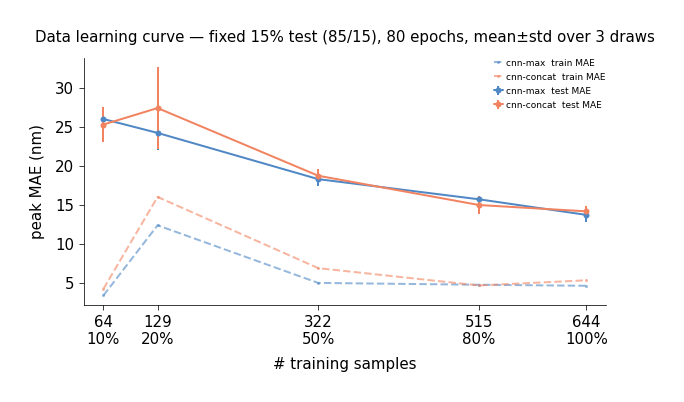

cnn-max: test MAE 26.0 nm @ 64 (10%) -> 13.7 nm @ 644 (100%)
cnn-concat: test MAE 25.3 nm @ 64 (10%) -> 14.1 nm @ 644 (100%)


In [3]:
fig,ax=plt.subplots(figsize=(8.5,5.2))
col={"max":C("aegean"),"concat":C("amber")}
for pool in POOLS:
    r=res[pool]; n=np.array(r["n"])
    ax.errorbar(n,r["te_mean"],yerr=r["te_std"],marker="o",capsize=3,color=col[pool],label=f"cnn-{pool}  test MAE")
    ax.plot(n,r["tr_mean"],ls="--",marker=".",color=col[pool],alpha=0.6,label=f"cnn-{pool}  train MAE")
ax.set_xlabel("# training samples"); ax.set_ylabel("peak MAE (nm)")
ax.set_title("Data learning curve — fixed 15% test (85/15), 80 epochs, mean±std over 3 draws")
ax.legend(fontsize=9)
ax.set_xticks(res["max"]["n"])
ax.set_xticklabels([f'{n}\n{int(f*100)}%' for n,f in zip(res["max"]["n"],res["max"]["frac"])])
plt.tight_layout(); fig.savefig("trained_models/data_learning_curve_85_15.png",dpi=130,bbox_inches="tight"); plt.show()
for pool in POOLS:
    r=res[pool]; print(f"cnn-{pool}: test MAE {r['te_mean'][0]:.1f} nm @ {r['n'][0]} (10%) -> {r['te_mean'][-1]:.1f} nm @ {r['n'][-1]} (100%)")

## 3. Ruggedness — does the peak jump between near-identical sequences?

Independent of any model: among FP pairs that are sequence-similar (4-mer-cosine prefilter, then exact alignment
identity), how much does the peak `0.5(|Δex|+|Δem|)` diverge as a function of identity? A **smooth** map drives
Δpeak→0 as identity→100%; a **rugged** one keeps a fat upper tail of large Δpeak even among near-twins. The
**median at high identity** is the intrinsic floor (best any model could do); the **upper tail** is the cliff
signal that caps a smoothly-interpolating model and inflates the test-error mean.

aligning 34718 candidate pairs (4-mer cos >= 0.6) ...


FLOOR  median Δpeak at identity>=0.98: 7.5 nm (n=1368)
RUGGED identity>=0.90 (n=20314): %Δ>20nm=58%  p95=103nm  max=218nm
identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm
  [0.70,0.85)    650    31.5   80.5  211.0    64%
  [0.85,0.90)  13097    31.5   75.0  217.5    64%
  [0.90,0.95)  12030    36.0   88.5  217.5    64%
  [0.95,0.98)   6916    23.5   71.2  201.5    54%
  [0.98,1.00)   1368     7.5   53.0  198.0    29%

top cliffs (id>=0.90, Δ>=30 nm; 10124 total):
  id 0.93  Δ   218  mNeptune684       (604,684) vs mTagBFP2          (399,454)
  id 0.93  Δ   216  mNeptune681       (604,681) vs mTagBFP2          (399,454)
  id 0.91  Δ   214  mNeptune684       (604,684) vs TagBFP            (402,457)
  id 0.91  Δ   213  mNeptune681       (604,681) vs TagBFP            (402,457)
  id 0.92  Δ   212  mCarmine          (603,675) vs mTagBFP2          (399,454)
  id 0.91  Δ   210  mTagBFP2          (399,454) vs TagRFP675         (598,675)
  id 0.91  Δ   209  secBFP2           (399,456) vs TagRFP

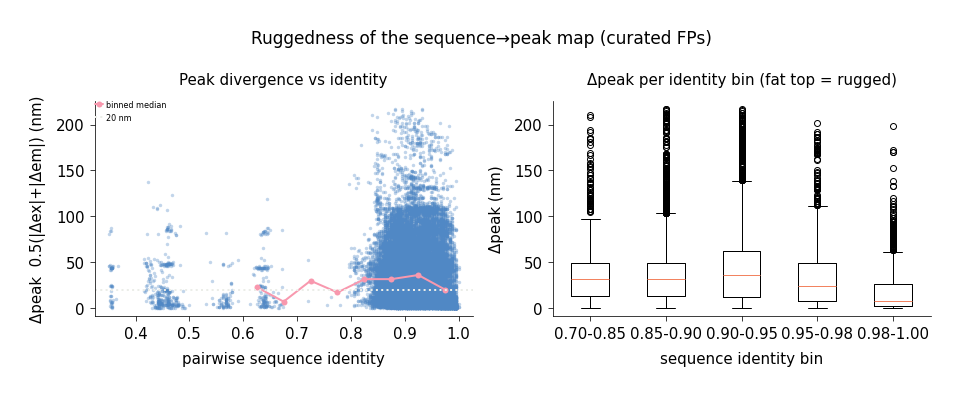

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
import biotite.sequence as bseq, biotite.sequence.align as balign
seqsR=[r["seq"] for r in rows]; namesR=[r["name"] for r in rows]
KMER_MIN=0.6                                                     # only align reasonably-similar pairs
Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqsR)
Sk=cossim(Xk); np.fill_diagonal(Sk,0.0)
iu=np.triu_indices(N,1); km=Sk[iu]; sel=np.where(km>=KMER_MIN)[0]
Ai=iu[0][sel]; Bi=iu[1][sel]
print(f"aligning {len(sel)} candidate pairs (4-mer cos >= {KMER_MIN}) ...")
MAT=balign.SubstitutionMatrix.std_protein_matrix()
def _ident(a,b):
    aln=balign.align_optimal(bseq.ProteinSequence(a),bseq.ProteinSequence(b),MAT,gap_penalty=(-10,-1))[0]
    return float(balign.get_sequence_identity(aln))
pid=np.array([_ident(seqsR[a],seqsR[b]) for a,b in zip(Ai,Bi)])
dpk=0.5*(np.abs(peaks[Ai,0]-peaks[Bi,0])+np.abs(peaks[Ai,1]-peaks[Bi,1]))

floor=np.median(dpk[pid>=0.98]); rug=pid>=0.90
print(f"FLOOR  median Δpeak at identity>=0.98: {floor:.1f} nm (n={(pid>=0.98).sum()})")
print(f"RUGGED identity>=0.90 (n={rug.sum()}): %Δ>20nm={100*np.mean(dpk[rug]>20):.0f}%  p95={np.percentile(dpk[rug],95):.0f}nm  max={dpk[rug].max():.0f}nm")
bins=[(0.70,0.85),(0.85,0.90),(0.90,0.95),(0.95,0.98),(0.98,1.001)]
print("identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm")
for lo,hi in bins:
    x=dpk[(pid>=lo)&(pid<hi)]
    if len(x): print(f"  [{lo:.2f},{hi:.2f})  {len(x):5d}  {np.median(x):6.1f}  {np.percentile(x,90):5.1f}  {x.max():5.1f}  {100*np.mean(x>20):4.0f}%")
cl=np.where((pid>=0.90)&(dpk>=30))[0]; cl=cl[np.argsort(-dpk[cl])][:12]
print(f"\ntop cliffs (id>=0.90, Δ>=30 nm; {((pid>=0.90)&(dpk>=30)).sum()} total):")
for k in cl:
    a,b=Ai[k],Bi[k]; print(f"  id {pid[k]:.2f}  Δ {dpk[k]:5.0f}  {namesR[a][:18]:18}({peaks[a,0]:.0f},{peaks[a,1]:.0f}) vs {namesR[b][:18]:18}({peaks[b,0]:.0f},{peaks[b,1]:.0f})")

fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].scatter(pid,dpk,s=12,alpha=0.35,color=C("aegean"))
be=np.linspace(0.6,1.0,9); ct=0.5*(be[:-1]+be[1:])
md_=[np.median(dpk[(pid>=be[i])&(pid<be[i+1])]) if ((pid>=be[i])&(pid<be[i+1])).any() else np.nan for i in range(8)]
ax[0].plot(ct,md_,"-o",color=C("rose"),lw=2,label="binned median"); ax[0].axhline(20,ls=":",color=C("gray"),label="20 nm")
ax[0].set_xlabel("pairwise sequence identity"); ax[0].set_ylabel("Δpeak  0.5(|Δex|+|Δem|) (nm)")
ax[0].set_title("Peak divergence vs identity"); ax[0].legend(fontsize=8)
ax[1].boxplot([dpk[(pid>=lo)&(pid<hi)] for lo,hi in bins], tick_labels=[f"{lo:.2f}-{hi:.2f}" for lo,hi in bins])
ax[1].set_xlabel("sequence identity bin"); ax[1].set_ylabel("Δpeak (nm)"); ax[1].set_title("Δpeak per identity bin (fat top = rugged)")
plt.suptitle("Ruggedness of the sequence→peak map (curated FPs)")
plt.tight_layout(); fig.savefig("trained_models/ruggedness.png",dpi=130,bbox_inches="tight"); plt.show()

## Notes
- This is a **data** learning curve (test error vs training-set size), distinct from the per-epoch curve.
  Test set is fixed (**15%**, seed 0) so points are comparable; training subsets are drawn from the
  remaining **85%** pool.
- Training-data fractions: **10 / 20 / 50 / 80 / 100%** of the 85% pool. 80 epochs per fit (no val selection).
  Bands are ±1 std over 3 random subset draws per size.
- A still-falling test curve at 100% ⇒ more data would help; a flattening curve + shrinking train↔test gap
  ⇒ data-limited returns. Compare cnn-max vs cnn-concat for which scales better.
- §3 ruggedness is a **data-landscape** diagnostic (model-free): peak divergence vs sequence identity among near-duplicate FP pairs. High-identity median = intrinsic floor; fat upper tail = spectral cliffs that cap a smooth model.